In [50]:
import pandas as pd
import geopandas as geopd

import os

import glob

In [2]:
root = "/media/iielse/T9/CAMELS-FI/data/"
src_dir = os.path.join(root, "raw_time_series")

In [11]:
attributes = ['humidity', 'pet', 'temperature_mean',
              'temperature_min', 'temperature_gmin','temperature_max',
               'precipitation', 'radiation_global', 'snow_depth']
dst_dir = os.path.join(root, "timeseries_by_attribute")

if not os.path.exists(dst_dir):
    os.makedirs(dst_dir)

In [12]:

for attribute in attributes:
    dfs = []
    glob_root = os.path.join(src_dir, attribute, '*.csv')
        # set because glob produces duplicates in some cases and I don't want to deal with them
    files = {file for file in glob.iglob(glob_root, recursive=True)}
    files = list(files)
    assert len(files) > 0, f"no files found with glob {glob_root}, check path"
    for path in files:
        df = pd.read_csv(path)
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
        dfs.append(df)
    weather = pd.concat(dfs)
    weather = weather.sort_index()
    
    dst_path = os.path.join(dst_dir, attribute + '.csv')
    weather.to_csv(dst_path)

<Axes: xlabel='date'>

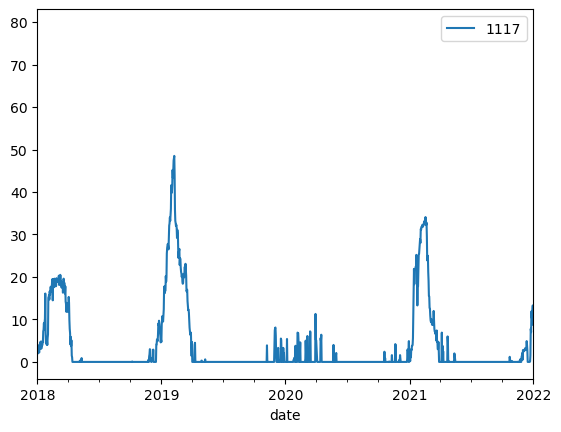

In [7]:
weather[['1117']].plot.line(xlim=("2018", "2022"))

In [39]:
"""
lokka_dir = "/media/iielse/T9/finland_climate/timeseries_by_attribute"

dst_dir = "/media/iielse/T9/CAMELS-FI/data/timeseries_by_attribute"


for attribute in attributes:
    src_path = os.path.join(lokka_dir, attribute + '.csv')
    lokka = pd.read_csv(src_path)
    lokka['date'] = pd.to_datetime(lokka['date'])
    lokka = lokka.set_index('date')

    replace_columns = lokka.columns

    dst_path = os.path.join(dst_dir, attribute + '.csv')
    dst = pd.read_csv(dst_path)
    dst['date'] = pd.to_datetime(dst['date'])
    dst = dst.set_index('date')

    dst = dst.assign(**lokka.to_dict(orient='series'))
    dst.to_csv(dst_path)
"""

In [65]:
"""
dst_dir = "/media/iielse/T9/CAMELS-FI/data/timeseries_by_attribute"
deletions = ['3829', '2681', '3875', '1344', '3858', '1212', '3009']
for attribute in attributes:
    src_path = os.path.join(dst_dir, attribute + '.csv')
    df = pd.read_csv(src_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    df = df.drop(deletions, axis=1)
    df.to_csv(src_path)
"""

In [64]:
df

,996,1003,1008,1009,1012,1014,1015,1018,1019,1021,...,937,941,943,946,951,961,964,1369,1366,1357
date,,,,,,,,,,,,,,,,,,,,,
1961-01-01,95.7,96.0,96.0,96.1,96.1,96.5,96.1,96.1,97.1,96.6,...,95.0,93.9,94.0,94.3,94.2,94.3,95.6,94.5,94.6,93.9
1961-01-02,94.3,94.4,94.7,94.7,94.8,95.1,94.5,94.6,95.7,94.9,...,94.1,94.3,94.3,94.6,94.8,95.8,95.1,93.6,93.6,93.2
1961-01-03,95.3,95.4,95.4,95.5,95.5,95.6,95.5,95.5,96.1,95.2,...,94.9,94.2,94.4,94.6,94.7,95.3,95.4,94.1,94.2,92.3
1961-01-04,92.0,92.0,92.2,92.2,92.3,92.6,92.1,92.1,93.0,92.9,...,91.7,92.4,92.2,92.3,92.4,92.8,92.5,92.3,92.0,92.0
1961-01-05,96.0,96.3,96.5,96.5,96.6,96.9,96.4,96.4,97.3,96.5,...,95.7,95.0,95.1,95.4,95.5,96.2,96.5,94.5,94.7,92.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,93.1,92.7,92.1,92.1,92.1,92.4,92.6,92.5,91.9,93.2,...,93.3,94.3,94.0,93.3,92.9,92.3,92.1,92.8,92.8,91.1
2023-12-28,94.9,94.4,94.4,94.4,94.4,94.3,94.5,94.5,94.5,94.5,...,93.9,94.4,94.1,93.7,93.5,93.4,94.2,91.3,91.9,87.4
2023-12-29,93.9,92.3,92.3,92.3,92.5,93.5,92.9,92.9,93.7,94.6,...,92.1,92.6,92.4,91.8,91.3,91.0,91.8,91.1,91.4,89.3


In [62]:
for value in df.columns:
    if not value in list(watersheds['Paikka_Id']):
        print(value)

3858
1212
3009


In [30]:
dst[replace_columns]

,2739,2740,1351,1354,1355,1356,1358,1357
date,,,,,,,,
1961-01-01,93.8,93.9,93.7,93.7,93.8,94.0,93.7,94.0
1961-01-02,93.1,93.1,93.1,93.1,93.1,93.1,93.6,93.1
1961-01-03,92.2,92.4,92.0,92.1,92.1,92.6,91.6,92.6
1961-01-04,91.8,91.9,91.6,91.6,91.7,92.1,92.0,92.1
1961-01-05,92.3,92.4,92.1,92.1,92.3,92.6,92.5,92.6
...,...,...,...,...,...,...,...,...
2023-12-27,90.9,90.9,90.9,90.9,90.9,90.8,91.9,90.8
2023-12-28,87.4,87.3,87.5,87.5,87.4,87.2,87.7,87.2
2023-12-29,89.5,89.5,89.7,89.7,89.6,89.3,89.3,89.3


In [33]:
test

,996,1003,1008,1009,1012,1014,1015,1018,1019,1021,...,937,941,943,946,951,961,964,1369,1366,1357
date,,,,,,,,,,,,,,,,,,,,,
1961-01-01,95.7,96.0,96.0,96.1,96.1,96.5,96.1,96.1,97.1,96.6,...,95.0,93.9,94.0,94.3,94.2,94.3,95.6,94.5,94.6,93.9
1961-01-02,94.3,94.4,94.7,94.7,94.8,95.1,94.5,94.6,95.7,94.9,...,94.1,94.3,94.3,94.6,94.8,95.8,95.1,93.6,93.6,93.2
1961-01-03,95.3,95.4,95.4,95.5,95.5,95.6,95.5,95.5,96.1,95.2,...,94.9,94.2,94.4,94.6,94.7,95.3,95.4,94.1,94.2,92.3
1961-01-04,92.0,92.0,92.2,92.2,92.3,92.6,92.1,92.1,93.0,92.9,...,91.7,92.4,92.2,92.3,92.4,92.8,92.5,92.3,92.0,92.0
1961-01-05,96.0,96.3,96.5,96.5,96.6,96.9,96.4,96.4,97.3,96.5,...,95.7,95.0,95.1,95.4,95.5,96.2,96.5,94.5,94.7,92.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,93.1,92.7,92.1,92.1,92.1,92.4,92.6,92.5,91.9,93.2,...,93.3,94.3,94.0,93.3,92.9,92.3,92.1,92.8,92.8,91.1
2023-12-28,94.9,94.4,94.4,94.4,94.4,94.3,94.5,94.5,94.5,94.5,...,93.9,94.4,94.1,93.7,93.5,93.4,94.2,91.3,91.9,87.4
2023-12-29,93.9,92.3,92.3,92.3,92.5,93.5,92.9,92.9,93.7,94.6,...,92.1,92.6,92.4,91.8,91.3,91.0,91.8,91.1,91.4,89.3


In [34]:
dst

,996,1003,1008,1009,1012,1014,1015,1018,1019,1021,...,937,941,943,946,951,961,964,1369,1366,1357
date,,,,,,,,,,,,,,,,,,,,,
1961-01-01,95.7,96.0,96.0,96.1,96.1,96.5,96.1,96.1,97.1,96.6,...,95.0,93.9,94.0,94.3,94.2,94.3,95.6,94.5,94.6,94.0
1961-01-02,94.3,94.4,94.7,94.7,94.8,95.1,94.5,94.6,95.7,94.9,...,94.1,94.3,94.3,94.6,94.8,95.8,95.1,93.6,93.6,93.1
1961-01-03,95.3,95.4,95.4,95.5,95.5,95.6,95.5,95.5,96.1,95.2,...,94.9,94.2,94.4,94.6,94.7,95.3,95.4,94.1,94.2,92.6
1961-01-04,92.0,92.0,92.2,92.2,92.3,92.6,92.1,92.1,93.0,92.9,...,91.7,92.4,92.2,92.3,92.4,92.8,92.5,92.3,92.0,92.1
1961-01-05,96.0,96.3,96.5,96.5,96.6,96.9,96.4,96.4,97.3,96.5,...,95.7,95.0,95.1,95.4,95.5,96.2,96.5,94.5,94.7,92.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,93.1,92.7,92.1,92.1,92.1,92.4,92.6,92.5,91.9,93.2,...,93.3,94.3,94.0,93.3,92.9,92.3,92.1,92.8,92.8,90.8
2023-12-28,94.9,94.4,94.4,94.4,94.4,94.3,94.5,94.5,94.5,94.5,...,93.9,94.4,94.1,93.7,93.5,93.4,94.2,91.3,91.9,87.2
2023-12-29,93.9,92.3,92.3,92.3,92.5,93.5,92.9,92.9,93.7,94.6,...,92.1,92.6,92.4,91.8,91.3,91.0,91.8,91.1,91.4,89.3
